# Model Validation for Production

**Module**: Production & Deployment | **Notebook 04**  
**Level**: Intermediate  
**Duration**: 45-60 minutes

---

## Learning Objectives

1. Use `ModelValidator` for pre-deployment validation
2. Understand parameter validity checks (NaN, Inf, magnitude)
3. Validate prediction sanity (no NaN, reasonable range)
4. Interpret GMM-specific diagnostic checks
5. Create custom validation rules for production requirements
6. Use `pipeline.validate()` as a deployment gate

## Prerequisites

- Completed Notebooks 01-03 (Predict, Save/Load, Pipeline)
- Familiarity with panel data models (PooledOLS, Fixed Effects, GMM)
- Basic understanding of model deployment concepts

## Setup

In [1]:
# Standard libraries
import copy
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# PanelBox imports
from panelbox.gmm import DifferenceGMM
from panelbox.models.static.fixed_effects import FixedEffects
from panelbox.production import ModelValidator, PanelPipeline

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

# Create directories
for d in [FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


### Load the Datasets

In [2]:
# Firm panel data
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")
df_new_firms = pd.read_csv(DATA_DIR / "new_firms.csv")

print("=== Firm Panel ===")
print(f"Shape: {df_firms.shape}")
print(
    f"Firms: {df_firms['firm_id'].nunique()}, Years: {df_firms['year'].min()}-{df_firms['year'].max()}"
)
display(df_firms.head(3))

=== Firm Panel ===
Shape: (2000, 7)
Firms: 100, Years: 2000-2019


,firm_id,year,investment,value,capital,sales,sector
0,1,2000,3.9817,6.8261,5.3317,4.5163,Manufacturing
1,1,2001,4.9167,6.2308,4.9664,7.2299,Manufacturing
2,1,2002,4.1953,4.6224,4.8215,5.7497,Manufacturing


In [3]:
# Bank LGD data
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

# Train/test split by time
df_lgd_train = df_lgd[df_lgd["month"] <= 12].copy()
df_lgd_test = df_lgd[df_lgd["month"] > 12].copy()

print("=== Bank LGD Panel ===")
print(f"Full shape: {df_lgd.shape}")
print(f"Train: {df_lgd_train.shape[0]} obs (months 1-12)")
print(f"Test:  {df_lgd_test.shape[0]} obs (months 13-15)")
print(f"Contracts: {df_lgd['contract_id'].nunique()}")
display(df_lgd.head(3))

=== Bank LGD Panel ===
Full shape: (3000, 7)
Train: 2400 obs (months 1-12)
Test:  600 obs (months 13-15)
Contracts: 200


,contract_id,month,lgd_logit,saldo_real,pib_growth,selic,collateral_ratio
0,1,1,0.2015,10.1292,2.3588,10.5697,0.5056
1,1,2,1.5349,10.1262,2.3773,9.7553,0.6011
2,1,3,2.0552,10.5844,2.8060,9.7743,0.5831


---

## Section 1: Why Validate Before Deploying?

A model that passes all statistical tests in a research setting may still **fail catastrophically** in production. Here's why:

| Failure Mode | Description | Example |
|---|---|---|
| **NaN parameters** | Numerical instability during estimation | Collinear instruments in GMM |
| **Exploding coefficients** | Parameters with unreasonable magnitude | |beta| > 1000 due to scaling |
| **Prediction NaN/Inf** | Model produces garbage output | Missing features in new data |
| **Invalid diagnostics** | Rejected Hansen J or AR(2) tests | Wrong instrument specification |
| **Instrument proliferation** | Too many instruments relative to groups | Over-identification in GMM |

**Validation acts as a gate**: the model must pass all checks before it can be deployed to production. This prevents broken models from generating predictions that inform business decisions.

PanelBox provides two complementary validation approaches:
- **`ModelValidator`**: A dedicated class for detailed, customizable validation
- **`pipeline.validate()`**: A quick shortcut built into `PanelPipeline`

---

## Section 2: ModelValidator Basics

`ModelValidator` takes a fitted model's results (and optionally the training data) and runs a suite of checks:
1. **Parameter validity** — no NaN, no Inf, reasonable magnitudes
2. **Prediction sanity** — predictions are finite and within a reasonable range
3. **GMM diagnostics** — Hansen J, AR(2), and instrument ratio (GMM models only)

Let's start by fitting a GMM model and running all validation checks.

In [4]:
# Estimate a GMM model
gmm_model = DifferenceGMM(
    data=df_lgd_train,
    dep_var="lgd_logit",
    lags=1,
    exog_vars=["saldo_real", "pib_growth", "selic", "collateral_ratio"],
    id_var="contract_id",
    time_var="month",
    gmm_max_lag=3,
    collapse=True,
    two_step=True,
    robust=True,
    time_dummies=False,
)
gmm_results = gmm_model.fit()

print("GMM Model Estimated")
print(f"Parameters: {len(gmm_results.params)}")
print(f"Observations: {gmm_results.nobs}")
print(f"Instruments: {gmm_results.n_instruments}")
print()
print("Coefficients:")
print(gmm_results.params)

GMM Model Estimated
Parameters: 5
Observations: 2000
Instruments: 6

Coefficients:
L1.lgd_logit        0.5913
saldo_real          0.1109
pib_growth          0.0456
selic              -0.0094
collateral_ratio    0.0820
dtype: float64


In [5]:
# Create validator
validator = ModelValidator(gmm_results, training_data=df_lgd_train)

# Run all checks
report = validator.run_all()

# Review report
print(report["summary"])
print(f"\nOverall: {'PASSED' if report['passed'] else 'FAILED'}")

Model Validation Report
  parameter_validity: PASSED
  predict_sanity: PASSED
  gmm_diagnostics: PASSED

Overall: PASSED


In [6]:
# Inspect individual checks in detail
print("Detailed Check Results:")
print("=" * 50)
for check in report["checks"]:
    name = check.get("name", "unknown")
    if check.get("skipped"):
        status = "SKIPPED"
    elif check.get("passed", True):
        status = "OK"
    else:
        status = "FAIL"
    print(f"  {name}: {status}")

    # Print additional details
    for key, val in check.items():
        if key not in ("name", "passed", "skipped"):
            if isinstance(val, float):
                print(f"    {key}: {val:.6f}")
            else:
                print(f"    {key}: {val}")

Detailed Check Results:
  parameter_validity: OK
    no_nan: True
    no_inf: True
    max_abs: 0.591334
    reasonable_magnitude: True
  predict_sanity: OK
    n_predictions: 2400
    n_nan: 200
    n_inf: 0
    mean: 2.387368
    std: 0.747857
  gmm_diagnostics: OK
    hansen_j_pvalue: 0.122744
    hansen_j_ok: True
    ar2_pvalue: 0.113752
    ar2_ok: True
    instrument_ratio: 0.030000
    instrument_ratio_ok: True


The `run_all()` method returns a dictionary with:
- `'passed'`: `True` if all checks passed
- `'checks'`: list of individual check results (each a dict)
- `'summary'`: formatted text summary

Each check includes a `'name'` and type-specific fields. Let's explore each check in detail.

---

## Section 3: Parameter Validity Checks

The `check_params()` method verifies that estimated coefficients are numerically valid:
- **No NaN**: Parameters must not be NaN (indicates estimation failure)
- **No Inf**: Parameters must not be infinite (numerical overflow)
- **Reasonable magnitude**: Max |coefficient| < 1000 (catches scaling issues)

These are basic sanity checks that catch the most common numerical issues.

In [7]:
# Check parameters on the well-specified model
param_check = validator.check_params()
print("Parameter Validity Check:")
print(f"  No NaN:               {param_check['no_nan']}")
print(f"  No Inf:               {param_check['no_inf']}")
print(f"  Max |beta|:           {param_check['max_abs']:.4f}")
print(f"  Reasonable magnitude: {param_check['reasonable_magnitude']}")

Parameter Validity Check:
  No NaN:               True
  No Inf:               True
  Max |beta|:           0.5913
  Reasonable magnitude: True


### Demonstrating Failure: Corrupted Parameters

In practice, NaN parameters can arise from:
- Perfect collinearity among regressors
- Singular instrument matrices in GMM
- Numerical overflow with poorly scaled data

Let's artificially corrupt a model to see how validation catches the problem.

In [8]:
# Artificially corrupt parameters to demonstrate failure detection
bad_results = copy.deepcopy(gmm_results)
bad_results.params.iloc[0] = np.nan
bad_results.params.iloc[2] = np.inf

print("Corrupted parameters:")
print(bad_results.params)
print()

# Validate the corrupted model
bad_validator = ModelValidator(bad_results)
bad_param_check = bad_validator.check_params()

print("Validation of corrupted model:")
print(f"  No NaN:               {bad_param_check['no_nan']}")  # False!
print(f"  No Inf:               {bad_param_check['no_inf']}")  # False!
print(f"  Max |beta|:           {bad_param_check['max_abs']}")
print(f"  Reasonable magnitude: {bad_param_check['reasonable_magnitude']}")

Corrupted parameters:
L1.lgd_logit           NaN
saldo_real          0.1109
pib_growth             inf
selic              -0.0094
collateral_ratio    0.0820
dtype: float64

Validation of corrupted model:
  No NaN:               False
  No Inf:               False
  Max |beta|:           nan
  Reasonable magnitude: False


In [9]:
# Demonstrate magnitude failure: extreme coefficient
extreme_results = copy.deepcopy(gmm_results)
extreme_results.params.iloc[1] = 5000.0  # Unreasonably large

extreme_validator = ModelValidator(extreme_results)
extreme_check = extreme_validator.check_params()

print("Extreme coefficient model:")
print(f"  No NaN:               {extreme_check['no_nan']}")
print(f"  No Inf:               {extreme_check['no_inf']}")
print(f"  Max |beta|:           {extreme_check['max_abs']:.1f}")
print(f"  Reasonable magnitude: {extreme_check['reasonable_magnitude']}")  # False!

Extreme coefficient model:
  No NaN:               True
  No Inf:               True
  Max |beta|:           5000.0
  Reasonable magnitude: False


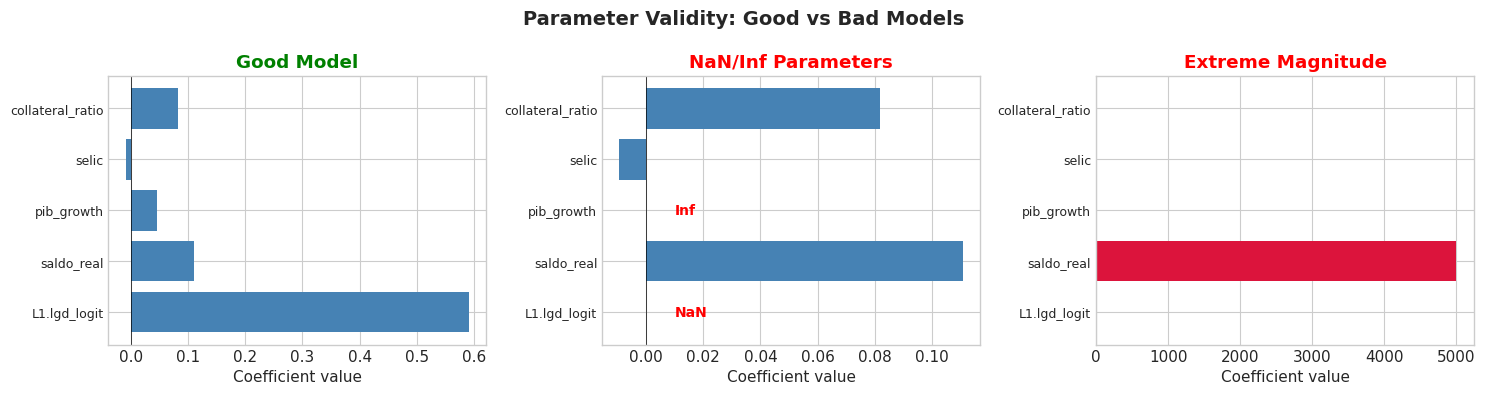

Figure saved.


In [10]:
# Visualize: comparison of good vs bad parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Good model
ax = axes[0]
colors = ["steelblue"] * len(gmm_results.params)
ax.barh(range(len(gmm_results.params)), gmm_results.params.values, color=colors)
ax.set_yticks(range(len(gmm_results.params)))
ax.set_yticklabels(gmm_results.params.index, fontsize=9)
ax.set_title("Good Model", fontweight="bold", color="green")
ax.set_xlabel("Coefficient value")
ax.axvline(x=0, color="black", linewidth=0.5)

# NaN model
ax = axes[1]
vals = bad_results.params.values.copy()
colors = ["crimson" if (np.isnan(v) or np.isinf(v)) else "steelblue" for v in vals]
# Replace NaN/Inf for plotting
plot_vals = np.where(np.isfinite(vals), vals, 0)
ax.barh(range(len(bad_results.params)), plot_vals, color=colors)
ax.set_yticks(range(len(bad_results.params)))
ax.set_yticklabels(bad_results.params.index, fontsize=9)
ax.set_title("NaN/Inf Parameters", fontweight="bold", color="red")
ax.set_xlabel("Coefficient value")
ax.axvline(x=0, color="black", linewidth=0.5)
# Mark NaN/Inf
for i, v in enumerate(bad_results.params.values):
    if np.isnan(v):
        ax.text(0.01, i, "NaN", color="red", fontweight="bold", va="center", fontsize=10)
    elif np.isinf(v):
        ax.text(0.01, i, "Inf", color="red", fontweight="bold", va="center", fontsize=10)

# Extreme model
ax = axes[2]
vals_ext = extreme_results.params.values.copy()
colors = ["crimson" if abs(v) > 1000 else "steelblue" for v in vals_ext]
ax.barh(range(len(extreme_results.params)), vals_ext, color=colors)
ax.set_yticks(range(len(extreme_results.params)))
ax.set_yticklabels(extreme_results.params.index, fontsize=9)
ax.set_title("Extreme Magnitude", fontweight="bold", color="red")
ax.set_xlabel("Coefficient value")
ax.axvline(x=0, color="black", linewidth=0.5)

plt.suptitle("Parameter Validity: Good vs Bad Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_parameter_validity.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

---

## Section 4: Prediction Sanity Checks

Even if parameters are valid, the model might still produce garbage predictions due to:
- Missing features in new data
- Extrapolation far outside the training range
- Interaction with entity effects that don't exist for new entities

The `check_predict_sanity()` method:
1. Calls `results.predict(test_data)` on the provided data
2. Counts NaN and Inf predictions
3. Reports prediction mean and standard deviation
4. Returns `'passed': True` if predict runs without errors

In [11]:
# Check predictions on test data
pred_check = validator.check_predict_sanity(test_data=df_lgd_test)

print("Prediction Sanity Check:")
print(f"  Passed:      {pred_check['passed']}")
print(f"  Predictions: {pred_check['n_predictions']}")
print(f"  NaN count:   {pred_check['n_nan']}")
print(f"  Inf count:   {pred_check['n_inf']}")
print(f"  Mean:        {pred_check['mean']:.4f}")
print(f"  Std:         {pred_check['std']:.4f}")

Prediction Sanity Check:
  Passed:      True
  Predictions: 600
  NaN count:   200
  Inf count:   0
  Mean:        2.7604
  Std:         0.6167


> **Note on NaN predictions in GMM**: For dynamic panel models, the first observation per entity has no lag available, so it produces a NaN prediction. This is expected behavior, not a validation failure. The `check_predict_sanity()` reports the counts so you can verify this is within expectations.

In [12]:
# Check predictions using training data (when no test data provided)
pred_check_train = validator.check_predict_sanity()  # Uses self.training_data

print("Prediction Sanity on Training Data:")
print(f"  Passed:      {pred_check_train['passed']}")
print(f"  Predictions: {pred_check_train['n_predictions']}")
print(f"  NaN count:   {pred_check_train['n_nan']}")
print(f"  Mean:        {pred_check_train['mean']:.4f}")
print(f"  Std:         {pred_check_train['std']:.4f}")

Prediction Sanity on Training Data:
  Passed:      True
  Predictions: 2400
  NaN count:   200
  Mean:        2.3874
  Std:         0.7479


In [13]:
# What happens with no data at all?
no_data_validator = ModelValidator(gmm_results)  # No training_data
no_data_check = no_data_validator.check_predict_sanity()  # No test_data either

print("Prediction check with no data:")
print(f"  Skipped: {no_data_check.get('skipped', False)}")
print(f"  Reason:  {no_data_check.get('reason', 'N/A')}")

Prediction check with no data:
  Skipped: True
  Reason:  No test data


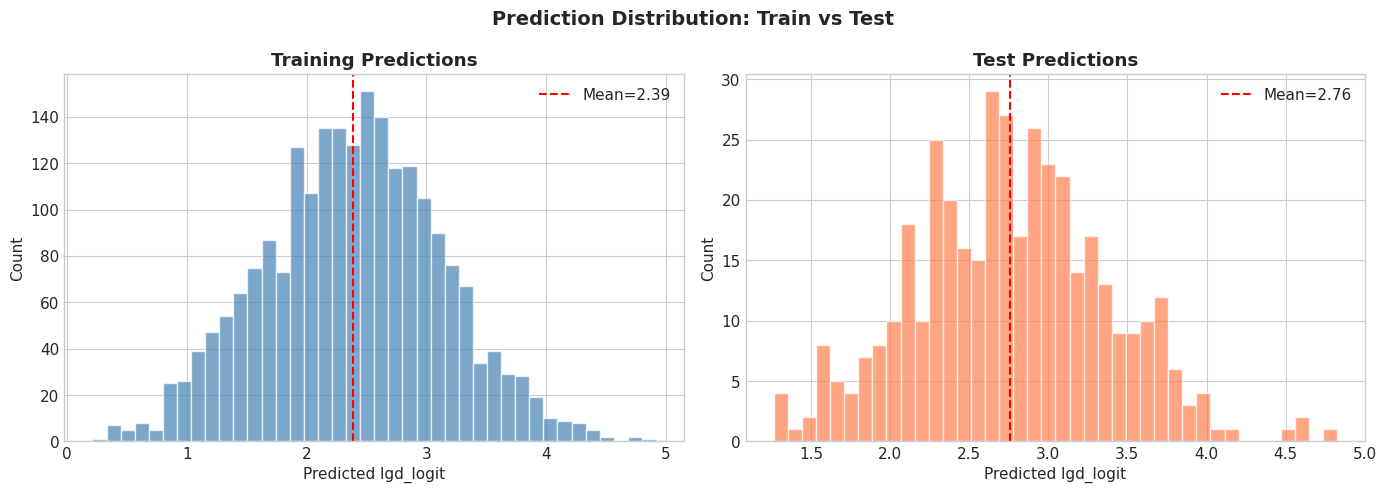

Figure saved.


In [14]:
# Visualize prediction distribution
preds_test = gmm_results.predict(df_lgd_test)
preds_train = gmm_results.predict(df_lgd_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training predictions
ax = axes[0]
valid_train = preds_train[np.isfinite(preds_train)]
ax.hist(valid_train, bins=40, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(
    np.nanmean(valid_train),
    color="red",
    linestyle="--",
    label=f"Mean={np.nanmean(valid_train):.2f}",
)
ax.set_title("Training Predictions", fontweight="bold")
ax.set_xlabel("Predicted lgd_logit")
ax.set_ylabel("Count")
ax.legend()

# Test predictions
ax = axes[1]
valid_test = preds_test[np.isfinite(preds_test)]
ax.hist(valid_test, bins=40, color="coral", alpha=0.7, edgecolor="white")
ax.axvline(
    np.nanmean(valid_test), color="red", linestyle="--", label=f"Mean={np.nanmean(valid_test):.2f}"
)
ax.set_title("Test Predictions", fontweight="bold")
ax.set_xlabel("Predicted lgd_logit")
ax.set_ylabel("Count")
ax.legend()

plt.suptitle("Prediction Distribution: Train vs Test", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_prediction_sanity.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

---

## Section 5: GMM-Specific Diagnostics

For GMM models, `ModelValidator` automatically detects the model type and runs additional diagnostic checks:

| Check | What It Tests | Good Result |
|-------|--------------|-------------|
| **Hansen J p-value** | Are instruments valid (orthogonal to errors)? | p > 0.10 (don't reject) |
| **AR(2) p-value** | Are moment conditions satisfied (no serial correlation in levels)? | p > 0.10 (don't reject) |
| **Instrument ratio** | Ratio of instruments to groups (N_instruments / N_groups) | ratio <= 1.0 |

These checks are critical for GMM models:
- **Hansen J rejection** means your instruments may be correlated with the error term
- **AR(2) rejection** means the moment conditions underlying the estimator are invalid
- **High instrument ratio** (> 1.0) indicates instrument proliferation, which weakens the Hansen J test and can lead to overfitting

In [15]:
# GMM-specific diagnostics
gmm_check = validator.check_gmm_diagnostics()

if gmm_check:
    print("GMM Diagnostic Check:")
    print(
        f"  Hansen J p-value:   {gmm_check['hansen_j_pvalue']:.4f} "
        f"({'OK' if gmm_check['hansen_j_ok'] else 'FAIL'})"
    )
    print(
        f"  AR(2) p-value:      {gmm_check['ar2_pvalue']:.4f} "
        f"({'OK' if gmm_check['ar2_ok'] else 'FAIL'})"
    )
    print(
        f"  Instrument ratio:   {gmm_check['instrument_ratio']:.4f} "
        f"({'OK' if gmm_check['instrument_ratio_ok'] else 'WARNING'})"
    )
else:
    print("Not a GMM model -- GMM diagnostics not available.")

GMM Diagnostic Check:
  Hansen J p-value:   0.1227 (OK)
  AR(2) p-value:      0.1138 (OK)
  Instrument ratio:   0.0300 (OK)


In [16]:
# Full run_all() to see how GMM checks appear in the combined report
full_report = validator.run_all()

print(full_report["summary"])
print()
print(f"Overall: {'PASSED' if full_report['passed'] else 'FAILED'}")
print()
print("All checks:")
for check in full_report["checks"]:
    print(f"  {check['name']}: {'OK' if check.get('passed', True) else 'FAIL'}")

Model Validation Report
  parameter_validity: PASSED
  predict_sanity: PASSED
  gmm_diagnostics: PASSED

Overall: PASSED

All checks:
  parameter_validity: OK
  predict_sanity: OK
  gmm_diagnostics: OK


### Demonstrating GMM Diagnostic Failure

Let's estimate a model with a questionable specification to see how validation catches diagnostic failures.

In [17]:
# Create a potentially problematic GMM: no instrument restriction
# Using default gmm_max_lag=None (uses all available lags as instruments)
try:
    gmm_many_inst = DifferenceGMM(
        data=df_lgd_train,
        dep_var="lgd_logit",
        lags=1,
        exog_vars=["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        id_var="contract_id",
        time_var="month",
        collapse=False,  # No collapsing = more instruments
        two_step=True,
        robust=True,
        time_dummies=False,
    )
    results_many = gmm_many_inst.fit()

    print(f"Instruments: {results_many.n_instruments}")
    print(f"Groups:      {results_many.n_groups}")
    print(f"Ratio:       {results_many.instrument_ratio:.4f}")
    print()

    # Validate
    val_many = ModelValidator(results_many, training_data=df_lgd_train)
    gmm_diag = val_many.check_gmm_diagnostics()

    print("GMM Diagnostics (many instruments):")
    print(
        f"  Hansen J p-value:  {gmm_diag['hansen_j_pvalue']:.4f} "
        f"({'OK' if gmm_diag['hansen_j_ok'] else 'FAIL'})"
    )
    print(
        f"  AR(2) p-value:     {gmm_diag['ar2_pvalue']:.4f} "
        f"({'OK' if gmm_diag['ar2_ok'] else 'FAIL'})"
    )
    print(
        f"  Instrument ratio:  {gmm_diag['instrument_ratio']:.4f} "
        f"({'OK' if gmm_diag['instrument_ratio_ok'] else 'WARNING'})"
    )

except Exception as e:
    print(f"Error: {e}")

Instruments: 59
Groups:      200
Ratio:       0.2950

GMM Diagnostics (many instruments):
  Hansen J p-value:  0.1589 (OK)
  AR(2) p-value:     0.1361 (OK)
  Instrument ratio:  0.2950 (OK)


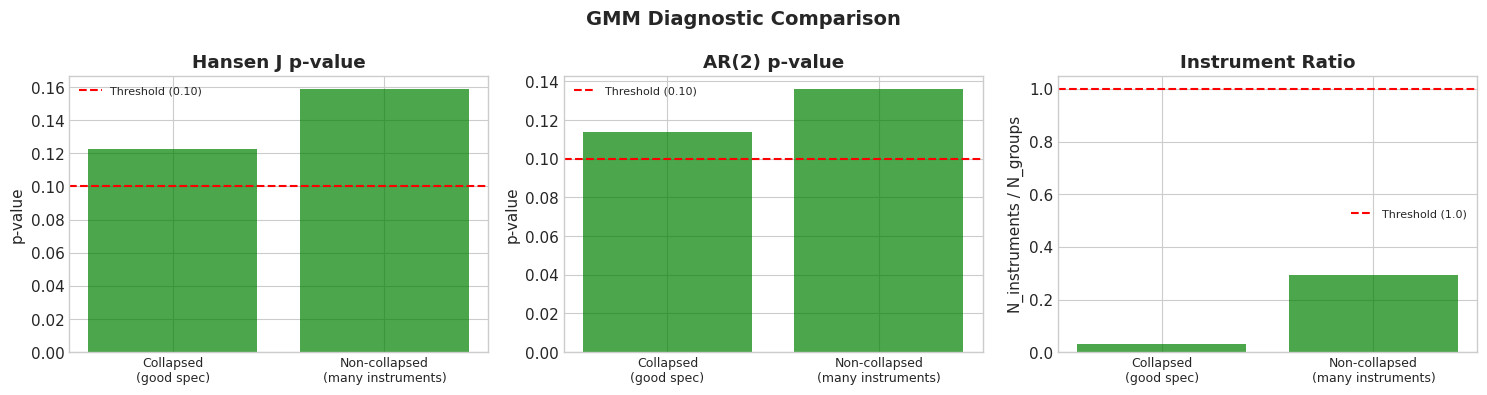

Figure saved.


In [18]:
# Visualize: diagnostic comparison between models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = {
    "Collapsed\n(good spec)": validator.check_gmm_diagnostics(),
}

# Add the many-instruments model if it was estimated
try:
    models_info["Non-collapsed\n(many instruments)"] = val_many.check_gmm_diagnostics()
except NameError:
    pass

model_names = list(models_info.keys())
x = np.arange(len(model_names))

# Hansen J p-value
ax = axes[0]
hansen_vals = [m["hansen_j_pvalue"] for m in models_info.values()]
colors_h = ["green" if v > 0.10 else "red" for v in hansen_vals]
ax.bar(x, hansen_vals, color=colors_h, alpha=0.7)
ax.axhline(y=0.10, color="red", linestyle="--", label="Threshold (0.10)")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_title("Hansen J p-value", fontweight="bold")
ax.set_ylabel("p-value")
ax.legend(fontsize=8)

# AR(2) p-value
ax = axes[1]
ar2_vals = [m["ar2_pvalue"] for m in models_info.values()]
colors_a = ["green" if v > 0.10 else "red" for v in ar2_vals]
ax.bar(x, ar2_vals, color=colors_a, alpha=0.7)
ax.axhline(y=0.10, color="red", linestyle="--", label="Threshold (0.10)")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_title("AR(2) p-value", fontweight="bold")
ax.set_ylabel("p-value")
ax.legend(fontsize=8)

# Instrument ratio
ax = axes[2]
ratio_vals = [m["instrument_ratio"] for m in models_info.values()]
colors_r = ["green" if v <= 1.0 else "orange" for v in ratio_vals]
ax.bar(x, ratio_vals, color=colors_r, alpha=0.7)
ax.axhline(y=1.0, color="red", linestyle="--", label="Threshold (1.0)")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_title("Instrument Ratio", fontweight="bold")
ax.set_ylabel("N_instruments / N_groups")
ax.legend(fontsize=8)

plt.suptitle("GMM Diagnostic Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_gmm_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

### Interpreting GMM Diagnostics

**Hansen J test** (overidentifying restrictions):
- H0: All instruments are valid (exogenous)
- If p < 0.10, instruments may be invalid
- **Caveat**: With too many instruments, the test has low power (almost always passes)

**AR(2) test** (autocorrelation in levels):
- H0: No second-order serial correlation in the first-differenced errors
- If p < 0.10, the moment conditions are likely violated
- We expect AR(1) to be significant (by construction), but AR(2) should not be

**Instrument ratio**:
- Ratio of instruments to groups (N_instruments / N_groups)
- Rule of thumb: ratio > 1.0 means too many instruments
- Using `collapse=True` reduces this ratio substantially

---

## Section 6: Pipeline validate() Shortcut

When using `PanelPipeline`, you don't need to create a `ModelValidator` manually. The `pipeline.validate()` method provides a quick deployment gate that runs the essential checks.

The pipeline's `validate()` checks:
1. Model has parameters
2. No NaN in parameters
3. Hansen J valid (GMM only)
4. AR(2) valid (GMM only)
5. Instrument ratio OK (GMM only)

In [19]:
# Create and fit a GMM pipeline
pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": True,
        "robust": True,
        "time_dummies": False,
    },
    name="LGD Production Model",
    description="Arellano-Bond GMM for LGD estimation",
)
pipeline.fit(df_lgd_train)

# Quick validation
report = pipeline.validate()

print(f"All checks passed: {report['passed']}")
print()
print("Individual checks:")
for check in report["checks"]:
    status = "PASS" if check["passed"] else "FAIL"
    print(f"  [{status}] {check['name']}")

if report["warnings"]:
    print()
    print("Warnings:")
    for w in report["warnings"]:
        print(f"  - {w}")

All checks passed: True

Individual checks:
  [PASS] has_params
  [PASS] no_nan_params
  [PASS] hansen_j_valid
  [PASS] ar2_valid
  [PASS] instrument_ratio_ok


In [20]:
# Using validate() as a deployment gate
if report["passed"]:
    save_path = MODELS_DIR / "lgd_validated.pkl"
    pipeline.save(save_path)
    print(f"Model PASSED validation -- deployed to {save_path}")
    print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")
else:
    print("Model FAILED validation:")
    for w in report["warnings"]:
        print(f"  - {w}")
    print("\nModel NOT deployed. Fix issues before retrying.")

Model PASSED validation -- deployed to ../outputs/models/lgd_validated.pkl
File size: 19.7 KB


In [21]:
# Compare: validate() on a static model (no GMM checks)
fe_pipeline = PanelPipeline(
    model_class=FixedEffects,
    model_params={
        "formula": "investment ~ value + capital + sales",
        "entity_col": "firm_id",
        "time_col": "year",
    },
    name="Firm Investment FE",
)
fe_pipeline.fit(df_firms)

fe_report = fe_pipeline.validate()

print("Fixed Effects pipeline validation:")
print(f"  Passed: {fe_report['passed']}")
print(f"  Checks: {len(fe_report['checks'])} (vs {len(report['checks'])} for GMM)")
for check in fe_report["checks"]:
    status = "PASS" if check["passed"] else "FAIL"
    print(f"  [{status}] {check['name']}")

print("\nNote: Static models only get parameter checks, no GMM diagnostics.")

Fixed Effects pipeline validation:
  Passed: True
  Checks: 2 (vs 5 for GMM)
  [PASS] has_params
  [PASS] no_nan_params

Note: Static models only get parameter checks, no GMM diagnostics.


In [22]:
# What happens when you validate before fitting?
unfitted_pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "id_var": "contract_id",
        "time_var": "month",
    },
    name="Unfitted Model",
)

unfitted_report = unfitted_pipeline.validate()
print("Unfitted pipeline validation:")
print(f"  Passed: {unfitted_report['passed']}")
print(f"  Warnings: {unfitted_report['warnings']}")

Unfitted pipeline validation:
  Passed: False
  Warnings: ['Model not fitted']


### ModelValidator vs pipeline.validate()

| Feature | `ModelValidator` | `pipeline.validate()` |
|---------|-----------------|----------------------|
| Prediction sanity check | Yes | No |
| Parameter magnitude check | Yes | No |
| GMM diagnostics | Yes | Yes |
| Requires training data | Optional | Not needed |
| Custom checks possible | Yes (subclass) | No |
| Output format | Detailed dict | Simple dict |

**Recommendation**: Use `pipeline.validate()` for quick checks during deployment, and `ModelValidator` for thorough validation during model development.

### Validation Summary Visualization

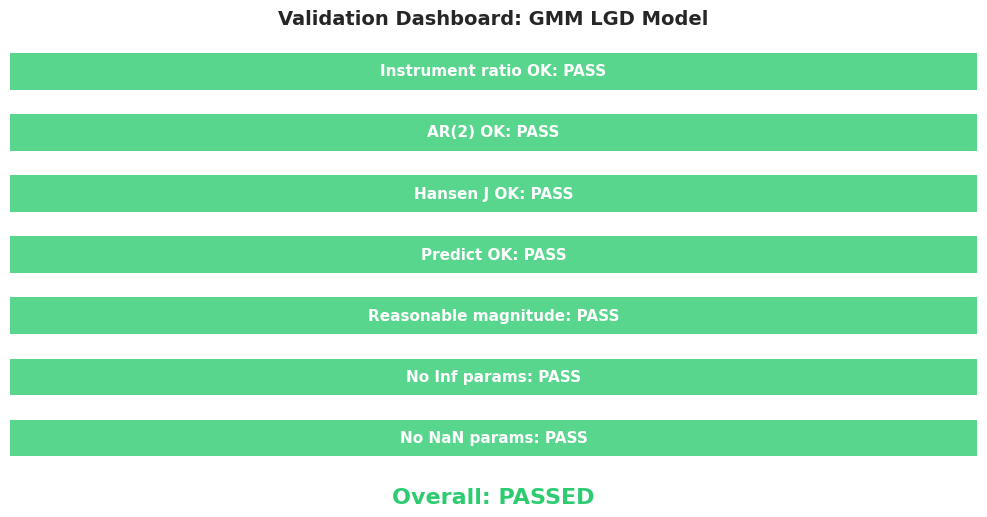

Figure saved.


In [23]:
# Summary figure: validation dashboard
fig, ax = plt.subplots(figsize=(10, 5))

# Collect all check results for the good GMM model
all_checks = [
    ("No NaN params", validator.check_params()["no_nan"]),
    ("No Inf params", validator.check_params()["no_inf"]),
    ("Reasonable magnitude", validator.check_params()["reasonable_magnitude"]),
    ("Predict OK", validator.check_predict_sanity(test_data=df_lgd_test).get("passed", False)),
]

gmm_diag_good = validator.check_gmm_diagnostics()
if gmm_diag_good:
    all_checks.extend(
        [
            ("Hansen J OK", gmm_diag_good["hansen_j_ok"]),
            ("AR(2) OK", gmm_diag_good["ar2_ok"]),
            ("Instrument ratio OK", gmm_diag_good["instrument_ratio_ok"]),
        ]
    )

check_names = [c[0] for c in all_checks]
check_results = [c[1] for c in all_checks]
colors = ["#2ecc71" if r else "#e74c3c" for r in check_results]

y_pos = range(len(check_names))
ax.barh(y_pos, [1] * len(check_names), color=colors, alpha=0.8, height=0.6)

for i, (name, result) in enumerate(all_checks):
    label = "PASS" if result else "FAIL"
    ax.text(
        0.5,
        i,
        f"{name}: {label}",
        ha="center",
        va="center",
        fontweight="bold",
        fontsize=11,
        color="white",
    )

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Validation Dashboard: GMM LGD Model", fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Overall result
overall = all(check_results)
fig.text(
    0.5,
    -0.02,
    f"Overall: {'PASSED' if overall else 'FAILED'}",
    ha="center",
    fontsize=16,
    fontweight="bold",
    color="#2ecc71" if overall else "#e74c3c",
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_validation_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

---

## Exercises

### Exercise 1 (Easy): Validate a PooledOLS Model

1. Estimate a `PooledOLS` model on the firm panel data (`investment ~ value + capital + sales`)
2. Create a `ModelValidator` with the results and training data
3. Run `check_params()`, `check_predict_sanity()`, and `check_gmm_diagnostics()`
4. Compare: What checks are run for a static model vs a GMM model? Is validation simpler?

In [24]:
# Exercise 1: Your code here


### Exercise 2 (Medium): Bad GMM Specification

1. Create a GMM model with a questionable specification:
   - Use `collapse=False` and no `gmm_max_lag` restriction
   - This will generate many instruments
2. Run `ModelValidator.run_all()` on the results
3. Also try corrupting the parameters (set one to NaN) and re-validate
4. Show which individual checks fail and explain why

In [25]:
# Exercise 2: Your code here


### Exercise 3 (Hard): Custom Validator

Create a `ProductionValidator` class that extends `ModelValidator` with three new checks:

1. `check_prediction_range(min_val, max_val)` — all predictions must fall within a business-defined range
2. `check_sign_constraints(param_name, expected_sign)` — verify that a specific coefficient has the expected sign (`'positive'` or `'negative'`)
3. `check_out_of_sample_rmse(test_data, dep_var, max_rmse)` — RMSE on test set must be below a threshold

Override `run_all()` to include your custom checks in the report.

Test your custom validator on the GMM LGD model with:
- Prediction range: [-5, 10]
- Sign constraint: `L1.lgd_logit` should be positive
- Out-of-sample RMSE < 2.0 on the test data

In [26]:
# Exercise 3: Your code here


---

## Summary

In this notebook, we learned:

- **`ModelValidator`** provides a detailed, customizable validation framework for fitted models
- **Parameter checks** catch NaN, Inf, and unreasonable coefficient magnitudes
- **Prediction sanity checks** verify that `predict()` produces finite, reasonable values
- **GMM diagnostics** automatically check Hansen J, AR(2), and instrument ratio for GMM models
- **`pipeline.validate()`** offers a quick deployment gate for the most critical checks
- **Custom validators** can extend `ModelValidator` with business-specific rules
- Always validate **before deploying** — a model that fails validation should never reach production

### Next Steps

- **Notebook 05**: Model Registry (`ModelRegistry`) for versioning, tracking, and lifecycle management